<a href="https://colab.research.google.com/github/ai-socialimpact/AnalyzeCommunityQuestions/blob/main/Clustering_SNEHA_ver3s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering apprach


## Challenges & solution:

### 1
#### problem 1: Hinglish sentances with users saying extra hello words, spell errors, different writing styles .

#### solution 1: this makes traditional appraoch prone to incorrect representation.. so we move to the best approach: Just do the best multi-lingual embedded to get the meaning of these 18000 - a one time translation


### 2
#### problem 2:  there are so many ways to cluster .. what would yeild the optimal cluster

#### solution 2:  run a 100 simulations (with GPU acceleration) in 10 minutes to find optimial clustering.  Metric : Dense enough info, but distint enough
e.g. all vaccine schedule needs to be into 1 folder, while (vaccine side-effects)  should go to another 2nd folder. [minimal over lap, so what user ask a question about fever after vaccine,  we don't misinterpret between the 2 vaccine folders]  

### 3

#### problem 3:  NGO challenge : i only have 3 days to vet a 100 FAQs. What will those 100? --> The challenge of minimal effort, max traffic coverge. What'should be in the questions that should get into this FAQ?  What are my community mostly looking for?

### solution 3:  get the top 10 clusters and thier whatsapp traffic, but we need to make it both intutive and comprehensive summary of what is inside the '"folder" "(cluster).   So we move to problem 4


### 4

#### problem 4: Make it intutive for NGO, especially if they want to see a "preview of represenative' Questions in  FAQ .  How to move from machine readable language (cluster/vector representation)  back to human readable language  ?  
##### Problem 4A.  A cluster id makes no sense for humans.  
##### Problem 4B. Reading 500 questions inside a single cluster will overwhelm the user!.
#### Problem 4C.  Understanding the scope of a cluster is also important. E.g. Where is the boundary between Vaccine Schedule vs Vaccine Side effects. So we can focus on the right micro-intents


#### solution 4: reverse canonical mapping from m/c understanble language (cluster's vector space) to  human understanble language (question space) by extracting all the 500 questions inside a cluster (thier frequency, thier diverstity) using a LLM  

### 5

#### problem 5: Now that we have identified the questions in the FAQ, how to create the answers

#### solution 5:  Using LLM Wiki and Answer consistency technique by having a team of virtual experts write the answering  to generate answers with 100 reasoning paths (100 team of experts apply different reasoning paths to get the answers, then do a auto validation). THen spot vet some of the answers by NGO experts , especially the important/senstive questions


### 7

#### problem  6: Since LLM is stateless, LLM will invent new taxonomy for every cluster. So the FAQ becomes different to read for human

#### solution 6:  Bring in a consistent domain taxonomy . Feed in the taxonomy identfied from LLM Wiki for consistent FAQ documention



## design
Step 1:

Step 2:

Step 3:

Step 4:

# The   Question log containing 18000+ whatsapp questions from community members

In [1]:
## The   Gliffic Question log containing 18000+ whatsapp questions from community members
FILE_PATH = '/content/glific_messages_funnel.csv'

In [21]:
import os
import pandas as pd



print("=== INITIALISING FILE INGESTION ===")
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Could not find '{FILE_PATH}'  .")

df = pd.read_csv(FILE_PATH)


df = df.dropna(subset=['body_final_phonetic'])
sentences = df['body_final_phonetic'].astype(str).tolist()

print("\n=== DATAFRAME   ===")
print("1. Total rows  :", len(df))
print("2. Total   in sentences list:", len(sentences))

print("\n=== FIRST 2 ROWS   ===")
for idx, s in enumerate(sentences[:2]):
    print(f"Row {idx}: {s[:120]}...")


=== INITIALISING FILE INGESTION ===

=== DATAFRAME   ===
1. Total rows  : 18044
2. Total   in sentences list: 18044

=== FIRST 2 ROWS   ===
Row 0: Aur baithane ka kab se shuru karun....
Row 1: "Main sunhin chutta mahina lagte hi bacche ko baithane ka aur usko daal ka paani aur ye vo halka-fulka kuch khilane ka k...


In [22]:

len(df)

18044

# this step is one-time only. Once we create the embedding, We save the embedded vectors into a int o harddisk and  re-use it 100's of simulations

## this embedding solves problem 1. (batch embedding with the SOTA Indic language embedding model)

#  A simple Table of Contents will do .

Here we download it - If this is not available for other NGOs, no worries , it can be human typed simple text paragraph  on the likely list of topics in the KB  . The SimpleIndex.md is more formal version, but a simple human typed list of topics version is enough.

In [23]:
!wget https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiSimpleVer3/SimpleIndex.md

--2026-10-07 07:28:52--  https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiSimpleVer3/SimpleIndex.md
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘SimpleIndex.md.1’

SimpleIndex.md.1        [  <=>               ] 251.73K  1.02MB/s    in 0.2s    

2026-10-07 07:28:52 (1.02 MB/s) - ‘SimpleIndex.md.1’ saved [257770]



In [24]:
!wget https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiVer2/index_stage_routing_protocol.md

--2026-10-07 07:28:53--  https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiVer2/index_stage_routing_protocol.md
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index_stage_routing_protocol.md.1’

index_stage_routing     [  <=>               ] 291.75K  1.17MB/s    in 0.2s    

2026-10-07 07:28:53 (1.17 MB/s) - ‘index_stage_routing_protocol.md.1’ saved [298757]



In [25]:
GOOGLE_GEMINI_API_KEY='YOUR_GEMINI_API_KEY'
#GOOGLE_GEMINI_API_KEY= = userdata.get('GOOGLE_GEMINI_API_KEY') #load from Secrets



In [ ]:
GEMINI_API_KEY = GOOGLE_GEMINI_API_KEY


# This is one time cost, and re-used across multiple simulations below. Also if this  is computed earlier, just re-use instead of calling LLM.

#Note: Also Cost of batch Embedding is much lower than usual LLM cost

# Just Run once and load from the saved file to conserve llm cost
Just load 'whatsapp_18k_gemini_embeddings.npy if you have saved it from previous runs.  

In [26]:
import numpy as np
import pandas as pd
import time
import random
from google import genai
from google.genai import types
from tqdm import tqdm
from sklearn.preprocessing import normalize

client = genai.Client(api_key=GEMINI_API_KEY)

production_df = df.copy()
#production_df = df.iloc[:453].copy()

production_sentences = production_df['body_final_phonetic'].astype(str).tolist()
print(f"• Ingesting all {len(production_sentences)} questions for embedding.")

production_vectors = []
BATCH_SIZE = 100
global_item_counter = 0
MAX_RETRIES = 5

print("\nStreaming batch of 100 rows   to Gemini Embedding 2 .")
for idx, i in enumerate(tqdm(range(0, len(production_sentences), BATCH_SIZE))):
    time.sleep(2)
    batch_strings = production_sentences[i:i+BATCH_SIZE]


    batch_contents = [
        types.Content(parts=[types.Part.from_text(text=s)])
        for s in batch_strings
    ]

    response = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.models.embed_content(
                model="gemini-embedding-2",
                contents=batch_contents,
                config=types.EmbedContentConfig(output_dimensionality=3072)
            )
            break

        except Exception as e:
            if attempt == MAX_RETRIES:
                print(f"\n❌   geminmi API error at Batch Index {idx} eben after {MAX_RETRIES} retyingg attempts: {e}")
                raise e

            backoff_delay = (2 ** attempt) + random.uniform(0.1, 0.9) + 30
            print(f"\nRate-limit on Batch {idx}. Retrying  ({attempt}/{MAX_RETRIES}) in {backoff_delay:.2f} ... Error: {e}")
            time.sleep(backoff_delay)

    for k in range(len(batch_strings)):
        vector_values = response.embeddings[k].values
        production_vectors.append(vector_values)

        #  diagnostic  every 500th
        if global_item_counter % 500 == 0:
            print(f"  [Sentence {global_item_counter}/{len(production_sentences)}] \"{production_sentences[global_item_counter][:40]}...\" ──► Embedded")

        global_item_counter += 1

# normalize full matrix
normalized_embeddings = normalize(np.array(production_vectors), norm='l2')

print("\n=== FINAL VERIFIED PRODUCTION MATRIX METRICS ===")
print(f"• Calculated Vector Matrix Shape: {normalized_embeddings.shape}")
print(f"• Total Safe Cloud API Calls Made: {idx + 1} network hits")


• Ingesting all 18044 questions for embedding.

Streaming batch of 100 rows   to Gemini Embedding 2 .


  1%|          | 1/181 [00:03<11:38,  3.88s/it]

  [Sentence 0/18044] "Aur baithane ka kab se shuru karun...." ──► Embedded


  3%|▎         | 6/181 [00:22<10:53,  3.73s/it]

  [Sentence 500/18044] "Yojana ki jaankaari..." ──► Embedded


...

 97%|█████████▋| 176/181 [09:37<00:15,  3.20s/it]

  [Sentence 17500/18044] "riport mein bacche ka video karna ya hai..." ──► Embedded


100%|██████████| 181/181 [09:52<00:00,  3.27s/it]

  [Sentence 18000/18044] "Ismen didi bolo kya karun iska hal batao..." ──► Embedded



=== FINAL VERIFIED PRODUCTION MATRIX METRICS ===
• Calculated Vector Matrix Shape: (18044, 3072)
• Total Safe Cloud API Calls Made: 181 network hits


In [27]:
import os
import pandas as pd

# 1. Configuration Check for Source Files
ROUTER_FILE = "index_stage_routing_protocol.md"
DATA_FILE = "glific_messages_funnel.csv"

print("=== CELL 1: INITIALISING STORAGE STREAM LAYER ===")

if not os.path.exists(ROUTER_FILE):
    raise FileNotFoundError(f"Could not locate '{ROUTER_FILE}'. Please upload it to your Colab sidebar.")

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Could not locate '{DATA_FILE}'. Please upload your source data CSV.")

# 2. Read Routing Protocol Text into Memory
with open(ROUTER_FILE, "r", encoding="utf-8") as f:
    VARIANT_2_ROUTING_INDEX = f.read()

# 3. Read Core DataFrame (Failsafe fallback)
df = pd.read_csv(DATA_FILE)
df = df.dropna(subset=['body_final_phonetic'])

print(f"✓ '{ROUTER_FILE}' streamed   (Size: {len(VARIANT_2_ROUTING_INDEX):,} characters)")
print(f"✓ '{DATA_FILE}' loaded . (Size: {len(df):,} messages)")


=== CELL 1: INITIALISING STORAGE STREAM LAYER ===
✓ 'index_stage_routing_protocol.md' streamed   (Size: 298,755 characters)
✓ 'glific_messages_funnel.csv' loaded . (Size: 18,044 messages)


In [28]:
import numpy as np

# 1. Save the    matrix
matrix_filename = "whatsapp_18k_gemini_embeddings.npy"
np.save(matrix_filename, normalized_embeddings)

print(f"🎉 Success! T matrix is  saved as '{matrix_filename}'")


🎉 Success! T matrix is  saved as 'whatsapp_18k_gemini_embeddings.npy'


In [14]:
import numpy as np


# Load the file
normalized_embeddings = np.load("/content/whatsapp_18k_gemini_embeddings.npy")

print(f"🎉 Success!   loaded back into 'normalized_embeddings'.")
print(f"📐 Verified Shape: {normalized_embeddings.shape}")



🎉 Success!   loaded back into 'normalized_embeddings'.
📐 Verified Shape: (1000, 3072)


In [29]:
import time
import pandas as pd
import numpy as np
import hdbscan

#  HIGH-PERFORMANCE GPU  ACCELERATION LINK
try:
    from cuml.manifold import UMAP as cuUMAP
    print("🚀  Accelerated GPU   Active! Offloading to VRAM Cores...")
    use_gpu = True
except ImportError:
    import umap
    print("⚠️ GPU cuML RAPIDS not detected in cell cache.  Try CPU...")
    use_gpu = False

print("=== grid seasrch ===")

# Search grid parameters mapping configuration
grid_components = [5, 8, 12, 15]
grid_neighbors = [8, 12, 15]

TARGET_MIN_CLUSTER = 8
TARGET_MIN_SAMPLES = 4

tuning_records = []
total_runs = len(grid_components) * len(grid_neighbors)
run_counter = 1

print(f"• Total configurations to benchmark: {total_runs} iterations.")
print(f"• Target  Baseline : min_cluster_size={TARGET_MIN_CLUSTER} | min_samples={TARGET_MIN_SAMPLES}")
print("• Optimization Metric Engine: Relative Validity Index (RVI) [Higher is Better]\n")

for comp in grid_components:
    for neigh in grid_neighbors:
        start_time = time.time()

        if use_gpu:
            reducer = cuUMAP(
                n_neighbors=neigh,
                n_components=comp,
                metric='cosine',
                random_state=42
            )
            embeddings_projected = reducer.fit_transform(normalized_embeddings)
        else:
            reducer = umap.UMAP(
                n_neighbors=neigh,
                n_components=comp,
                metric='cosine',
                random_state=42,
                n_jobs=-1
            )
            embeddings_projected = reducer.fit_transform(normalized_embeddings)

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=TARGET_MIN_CLUSTER,
            min_samples=TARGET_MIN_SAMPLES,
            metric='euclidean',
            cluster_selection_method='eom',
            gen_min_span_tree=True,
            prediction_data=True
        )
        labels = clusterer.fit_predict(embeddings_projected)

        # 3. Extract topological validity scores e
        discovered_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
        noise_count = np.sum(labels == -1)
        noise_pct = (noise_count / len(labels)) * 100

        try:
            rvi_score = clusterer.relative_validity_
        except Exception as e:
            rvi_score = -1.0

        elapsed_time = time.time() - start_time

        print(f"[{run_counter}/{total_runs}] Space Depth: {comp}D | Neighbors: {neigh} ──► Discovered: {discovered_clusters} FAQs | Noise: {noise_pct:.1f}% | True RVI Score: {rvi_score:.4f} | Time: {elapsed_time:.1f}s")

        tuning_records.append({
            "UMAP_Components": comp,
            "UMAP_Neighbors": neigh,
            "Total_Clusters_Found": discovered_clusters,
            "Noise_Percentage": noise_pct,
            "Optimization_RVI_Score": rvi_score
        })
        run_counter += 1

# 4.  RANK RESULTS
tuning_results_df = pd.DataFrame(tuning_records)
tuning_results_df = tuning_results_df.sort_values(by='Optimization_RVI_Score', ascending=False).reset_index(drop=True)

print("\n" + "="*75)
print("🏆 WINNING MICRO-INTENT CLUSTERING CONFIGURATION")
print("="*75)
winner = tuning_results_df.iloc[0]
print(f" • Winner UMAP Target Dimensions : {int(winner['UMAP_Components'])}D")
print(f" • Winner UMAP View Lens Neighbors: {int(winner['UMAP_Neighbors'])}")
print(f" • Maximum Micro-Intents Isolated : {int(winner['Total_Clusters_Found'])} separate FAQ entries")
print(f" • Optimal Topology RVI Score    : {winner['Optimization_RVI_Score']:.4f}")
print(f" • Noise Verification Percentage  : {winner['Noise_Percentage']:.2f}%")
print("="*75)


🚀  Accelerated GPU   Active! Offloading to VRAM Cores...
=== grid seasrch ===
• Total configurations to benchmark: 12 iterations.
• Target  Baseline : min_cluster_size=8 | min_samples=4
• Optimization Metric Engine: Relative Validity Index (RVI) [Higher is Better]

[1/12] Space Depth: 5D | Neighbors: 8 ──► Discovered: 468 FAQs | Noise: 25.1% | True RVI Score: 0.2763 | Time: 7.3s
[2/12] Space Depth: 5D | Neighbors: 12 ──► Discovered: 411 FAQs | Noise: 26.8% | True RVI Score: 0.2834 | Time: 2.3s
[3/12] Space Depth: 5D | Neighbors: 15 ──► Discovered: 352 FAQs | Noise: 25.8% | True RVI Score: 0.3131 | Time: 3.7s
[4/12] Space Depth: 8D | Neighbors: 8 ──► Discovered: 470 FAQs | Noise: 25.5% | True RVI Score: 0.3021 | Time: 2.8s
[5/12] Space Depth: 8D | Neighbors: 12 ──► Discovered: 401 FAQs | Noise: 25.5% | True RVI Score: 0.2960 | Time: 4.1s
[6/12] Space Depth: 8D | Neighbors: 15 ──► Discovered: 349 FAQs | Noise: 25.5% | True RVI Score: 0.3020 | Time: 2.8s
[7/12] Space Depth: 12D | Neighbor

In [30]:
import pandas as pd
import numpy as np
import hdbscan

try:
    from cuml.manifold import UMAP as cuUMAP
    reducer_production = cuUMAP(n_neighbors=12, n_components=8, metric='cosine', random_state=42)
    print("🚀 Compressing 18,044  SNEHA Gliffic question funnel  rows into the winning 8D map...")
except ImportError:
    import umap
    reducer_production = umap.UMAP(n_neighbors=12, n_components=8, metric='cosine', random_state=42, n_jobs=-1)
    print(" CPU Multi-threading...")

# 1. Project the  matrix into the  8D mapp
umap_embeddings_production = reducer_production.fit_transform(normalized_embeddings)

# 2. Run    micro-intent cluster scan
clusterer_production = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=4,
    metric='euclidean',
    cluster_selection_method='eom',
    gen_min_span_tree=True
)
df['cluster_id'] = clusterer_production.fit_predict(umap_embeddings_production)

# 3.  Matrix  Metrics
total_production_clusters = df['cluster_id'].nunique() - (1 if -1 in df['cluster_id'].values else 0)
noise_production_count = len(df[df['cluster_id'] == -1])
noise_production_pct = (noise_production_count / len(df)) * 100

print("\n" + "="*60)
print("🎯 MICRO-INTENT MASTER COORDINATE METRICS LOCKED")
print("="*60)
print(f"• Total Fine-Grained FAQs Discovered : {total_production_clusters} micro-chapters")
print(f"• System Noise Filtered Out         : {noise_production_count:,} rows ({noise_production_pct:.2f}%)")
print(f"• Mathematical Validation RVI Score  : {clusterer_production.relative_validity_:.4f}")
print("="*60)

print("\n📊 NEW TOP 5 LARGEST MICRO-INTENT CLUSTERS (BY MENTION VOLUME):")
print(df[df['cluster_id'] != -1]['cluster_id'].value_counts().head(5))


🚀 Compressing 18,044  SNEHA Gliffic question funnel  rows into the winning 8D map...

🎯 MICRO-INTENT MASTER COORDINATE METRICS LOCKED
• Total Fine-Grained FAQs Discovered : 401 micro-chapters
• System Noise Filtered Out         : 4,601 rows (25.50%)
• Mathematical Validation RVI Score  : 0.2960

📊 NEW TOP 5 LARGEST MICRO-INTENT CLUSTERS (BY MENTION VOLUME):
cluster_id
31     469
215    407
236    276
14     236
351    232
Name: count, dtype: int64


# solve the problem 4 (make it intuttive ),

### but we need the right inputs to LLM (garbge n , garbage out).. lets gather the right input from cluster , so that can feed it to LLM

In [31]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

print(" right input foir llm ===")

def build_cluster_context_payload(df_master, normalized_matrix, cluster_id, max_tier1=200, max_tier2=100):
    """
    geometric distance calculations to pull
    1. heavy volume repeaters - based on how many gliffic users asked this .
    2. diversity gliffic question in a cluster
    """

    cluster_indices = df_master[df_master['cluster_id'] == cluster_id].index.tolist()
    cluster_embeddings = normalized_matrix[cluster_indices]
    cluster_df_slice = df_master.loc[cluster_indices].copy()
    string_counts_loop = cluster_df_slice['body_final_phonetic'].value_counts()
    cluster_volume = len(cluster_df_slice)

    # 2.   the  centroid vector of this cluster
    topic_centroid = np.mean(cluster_embeddings, axis=0).reshape(1, -1)

    # 3.   repeating strings from long-tail   (Count == 1)
    unique_phrases = string_counts_loop[string_counts_loop == 1].index.tolist()
    unique_indices = cluster_df_slice[cluster_df_slice['body_final_phonetic'].isin(unique_phrases)].index.tolist()

    #  if a cluster is hyper-dense and contains zero unique queries
    if len(unique_indices) == 0:
        selected_diversity_phrases = string_counts_loop.tail(max_tier2).index.tolist()
    else:
        unique_embeddings = normalized_matrix[unique_indices]
        unique_texts = cluster_df_slice.loc[unique_indices, 'body_final_phonetic'].tolist()

        # ---  find DIVERSITY of questions  ---
        selected_diversity_phrases = []
        remaining_embeddings = list(unique_embeddings)
        remaining_texts = list(unique_texts)

        distances_to_centroid = cdist(topic_centroid, unique_embeddings, metric='cosine')
        first_pick_idx = np.argmax(distances_to_centroid)
        selected_diversity_phrases.append(remaining_texts.pop(first_pick_idx))
        current_selected_vectors = [remaining_embeddings.pop(first_pick_idx)]


        while len(selected_diversity_phrases) < max_tier2 and len(remaining_texts) > 0:
            dist_matrix = cdist(remaining_embeddings, current_selected_vectors, metric='cosine')
            min_distances_to_pool = np.min(dist_matrix, axis=1)
            next_pick_idx = np.argmax(min_distances_to_pool)
            selected_diversity_phrases.append(remaining_texts.pop(next_pick_idx))
            current_selected_vectors.append(remaining_embeddings.pop(next_pick_idx))

    tier_1_payload = [f"Count: {count} | {phrase}" for phrase, count in string_counts_loop[string_counts_loop >= 2].head(max_tier1).items()]
    tier_2_payload = [f"Count: {int(string_counts_loop[phrase])} | {phrase}" for phrase in selected_diversity_phrases]

    return tier_1_payload, tier_2_payload, cluster_volume

# =====================================================================
# 🧪 UNIT TEST  :
# =====================================================================
#   active macro-clusters from the newly optimized 419-space
valid_clusters_df = df[df['cluster_id'] != -1]
cluster_counts = valid_clusters_df['cluster_id'].value_counts()
top_macro_clusters = cluster_counts.index.tolist()

print("\n" + "🔬 " * 20 + "STARTING MANUAL HARNESS UNIT TEST" + " 🔬" * 20)
for idx, cid in enumerate(top_macro_clusters[:2], 1):
    t1, t2, vol = build_cluster_context_payload(df, normalized_embeddings, cid)

    print(f"\n📌 UNIT TEST HARNESS [STEP {idx}/2] ──► Target Cluster ID: #{cid} | Total Volume: {vol} rows")
    print("-" * 100)
    # Truncate strings to match the required visual inspection constraint rules
    print(f"📦 TIER_1_FREQUENCY (Top 2 lines, truncated): {[x[:100] for x in t1[:2]]}")
    print(f"📦 TIER_2_DIVERSITY (Top 2 lines, truncated): {[x[:100] for x in t2[:2]]}")
    print(f"✓ Local structural compilation verified for Cluster #{cid}.")

print("\n" + "=" * 90)
print("✅ UNIT TEST SUCCESSFUL: Payload factory engine operates flawlessly at zero API cost!")
print("=" * 90)


 right input foir llm ===

🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 STARTING MANUAL HARNESS UNIT TEST 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬

📌 UNIT TEST HARNESS [STEP 1/2] ──► Target Cluster ID: #31 | Total Volume: 469 rows
----------------------------------------------------------------------------------------------------
📦 TIER_1_FREQUENCY (Top 2 lines, truncated): ['Count: 6 | Mera baby six month ka hua hai abhi usko 3:30 mahine ka sui lagaya hai 3 din ho gaya hai ', 'Count: 3 | Jahan per sui mare Na vahin per guard jaisa hua Hai Baki aur kuchh nahin']
📦 TIER_2_DIVERSITY (Top 2 lines, truncated): ['Count: 1 | Injection le hu', 'Count: 1 | Opv 2 kya hai']
✓ Local structural compilation verified for Cluster #31.

📌 UNIT TEST HARNESS [STEP 2/2] ──► Target Cluster ID: #215 | Total Volume: 407 rows
----------------------------------------------------------------------------------------------------
📦 TIER_1_FREQUENCY (Top 2 lines, truncated): ['Count: 3 | Pregnancy me pet upar ki traf ch

In [32]:
build_cluster_context_payload(df, normalized_embeddings, cluster_id = 44 , max_tier1=10, max_tier2=5)

(['Count: 2 | Sex ke bare me'],
 ['Count: 1 | Youjna k bare me',
  'Count: 1 | Kya is condition mai sex kar sakte hai',
  'Count: 1 | Xxx krne ke time me zada ho ta hai',
  'Count: 1 | Sexs ke bare me',
  'Count: 1 | Sex kar sake hai'],
 10)

In [35]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

print("= find the hill =")

def generate_3d_skyline_plot(df_master, top_n_slots=40):
    """
       plot from the active cluster_id  .
    The Y-Axis explicitly maps the  gliffic traffic size volume of each discovered micro-intent topic.
    """

    valid_df = df_master[df_master['cluster_id'] != -1]
    cluster_counts = valid_df['cluster_id'].value_counts()

    top_cids = cluster_counts.head(top_n_slots).index.tolist()
    total_raw_rows = len(df_master)

    grid_cols = 5
    grid_rows = int(np.ceil(top_n_slots / grid_cols))

    x_coords = []
    z_coords = []
    for r in range(grid_rows):
        for c in range(grid_cols):
            x_coords.append(c * 2)
            z_coords.append(r * 2)

    fig = go.Figure()
    print(f"Building 3D box  the top {top_n_slots} micro-intent channels...")

    for idx, cid in enumerate(top_cids):
        if idx >= len(x_coords):
            break
        x = x_coords[idx]
        z = z_coords[idx]

        h = int(cluster_counts[cid])
        pct_share = (h / total_raw_rows) * 100

        sample_phrase = df_master[df_master['cluster_id'] == cid]['body_final_phonetic'].iloc[0]
        if len(sample_phrase) > 45:
            sample_phrase = sample_phrase[:45] + "..."

        hover_text = (
            f"<b>Chapter Slot {idx+1} (Cluster ID: {cid})</b><br>"
            f"📊 Traffic Volume Size (Y-Axis): {h} inquiries<br>"
            f"📈 Channel Share Proportions   : {pct_share:.2f}% traffic<br>"
            f"🗣️ Raw Sample Vector Snippet   : '{sample_phrase}'"
        )

        box_color = f"rgb({int(31 + (idx*2.5))}, {int(119 + (idx*1.5))}, {int(180 + (idx*0.8))})"

        fig.add_trace(go.Mesh3d(
            x=[x-0.6, x+0.6, x+0.6, x-0.6, x-0.6, x+0.6, x+0.6, x-0.6],
            y=[0, 0, h, h, 0, 0, h, h],
            z=[z-0.6, z-0.6, z-0.6, z-0.6, z+0.6, z+0.6, z+0.6, z+0.6],
            i=[7, 0, 0, 0, 4, 4, 2, 6, 4, 0, 3, 7],
            j=[3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
            k=[0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 4],
            color=box_color,
            opacity=0.95,
            hoverinfo="text",
            text=hover_text,
            name=f"Slot {idx+1}"
        ))

    fig.update_layout(
        title=f' Gliffic WhatsApp Traffic Across Top {top_n_slots} Micro-Intents',
        title_font=dict(size=18, family="Arial, sans-serif", color="white"),
        template="plotly_dark",
        width=1300,
        height=850,
        scene=dict(
            xaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            yaxis=dict(title='Traffic Mention Volume (Y-AXIS HEIGHT)', titlefont=dict(size=12, color='#00ffcc'), showgrid=True),
            zaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            camera=dict(eye=dict(x=1.8, y=1.5, z=1.5))
        ),
        showlegend=False
    )
    return fig

# =====================================================================
# unit test
# =====================================================================
interactive_skyline_fig = generate_3d_skyline_plot(df, top_n_slots=20)
interactive_skyline_fig.show()


= find the hill =
Building 3D box  the top 20 micro-intent channels...


In [ ]:
interactive_skyline_fig = generate_3d_skyline_plot(df, top_n_slots=100)
interactive_skyline_fig.show()

Building 3D box  the top 100 micro-intent channels...


In [36]:
import numpy as np
import pandas as pd

print("=== CELL 4.6: GENERATING TWO-SCENARIO EXECUTIVE WORKLOAD MATRIX ===")

def calculate_executive_scenarios(df_master, scenario_a_count=5, scenario_b_count=30):
    """
    Analyzes active cluster distributions to dynamically output a 10-row matrix
    and explicitly prints out the two executive project options in plain English.
    """
    total_raw_rows = len(df_master)

    # Isolate genuine   queries
    valid_medical_df = df_master[df_master['cluster_id'] != -1]
    total_clean_medical_queries = len(valid_medical_df)

    # Extract ranked volume metrics
    cluster_volumes = valid_medical_df['cluster_id'].value_counts()
    total_discovered_chapters = len(cluster_volumes)

    #   10-step milestones
    milestone_steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    matrix_records = []

    for step in milestone_steps:
        cumulative_mentions = int(cluster_volumes.head(step).sum())
        global_raw_coverage = (cumulative_mentions / total_raw_rows) * 100
        clinical_deflection_rate = (cumulative_mentions / total_clean_medical_queries) * 100

        if step <= 10:
            rec_tag = "Minimal Baseline (Misses long-tail anxieties)"
        elif step <= 30:
            rec_tag = "Highly Optimized (Strongest return for understaffed NGO)"
        else:
            rec_tag = "Maximum Coverage (Extremely heavy copywriting workload)"

        matrix_records.append({
            "Top_Chapters_Included": f"Top {step} Chapters",
            "Inquiries_Resolved": cumulative_mentions,
            "Global_Channel_Traffic_Share": f"{global_raw_coverage:.2f}%",
            "Clinical_Deflection_Accuracy": f"{clinical_deflection_rate:.2f}% 🔥",
            "NGO_Committee_Writing_Workload": f"Write {step} Answers",
            "Strategic_Recommendation_Matrix": rec_tag
        })

    decision_matrix_df = pd.DataFrame(matrix_records)

     # Scenario A
    vol_a = int(cluster_volumes.head(scenario_a_count).sum())
    pct_a = (vol_a / total_raw_rows) * 100

    # Scenario B
    vol_b = int(cluster_volumes.head(scenario_b_count).sum())
    pct_b = (vol_b / total_raw_rows) * 100

    # =====================================================================
    # 🗣️ THE REQUESTED STRATEGIC EXECUTIVE PRINT BLOCK
    # =====================================================================
    print("\n" + "📢 " * 15 + "EXECUTIVE BLUEPRINT ROADMAP SCENARIOS" + " 📢" * 15)
    print("-" * 105)
    print(f"🔹 SCENARIO A: If you do {scenario_a_count} books, then {pct_a:.2f}% of traffic can be routed there.")
    print(f"               (Requires writing only {scenario_a_count} answers; covers core fundamentals like basic newborn shots).")
    print("-" * 105)
    print(f"🔸 SCENARIO B: If you do {scenario_b_count} books, then {pct_b:.2f}% of traffic can be routed there.")
    print(f"               (Requires writing {scenario_b_count} answers; provides an optimized automated vector search shield).")
    print("-" * 105 + "\n")

    print(f"📊 RAW DATA STATISTICS:")
    print(f" • Total Channels Logs Ingested    : {total_raw_rows:,} rows")
    print(f" • Active Micro-Intents Isolated   : {total_discovered_chapters} distinct FAQ entries\n")

    return decision_matrix_df

# =====================================================================
# EXECUTE CORE RUNNER PASS
# =====================================================================
executive_table_df = calculate_executive_scenarios(df, scenario_a_count=5, scenario_b_count=30)
display(executive_table_df)


=== CELL 4.6: GENERATING TWO-SCENARIO EXECUTIVE WORKLOAD MATRIX ===

📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 EXECUTIVE BLUEPRINT ROADMAP SCENARIOS 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢
---------------------------------------------------------------------------------------------------------
🔹 SCENARIO A: If you do 5 books, then 8.98% of traffic can be routed there.
               (Requires writing only 5 answers; covers core fundamentals like basic newborn shots).
---------------------------------------------------------------------------------------------------------
🔸 SCENARIO B: If you do 30 books, then 25.27% of traffic can be routed there.
               (Requires writing 30 answers; provides an optimized automated vector search shield).
---------------------------------------------------------------------------------------------------------

📊 RAW DATA STATISTICS:
 • Total Channels Logs Ingested    : 18,044 rows
 • Active Micro-Intents Isolated   : 401 distinct FAQ entries



,Top_Chapters_Included,Inquiries_Resolved,Global_Channel_Traffic_Share,Clinical_Deflection_Accuracy,NGO_Committee_Writing_Workload,Strategic_Recommendation_Matrix
0,Top 5 Chapters,1620,8.98%,12.05% 🔥,Write 5 Answers,Minimal Baseline (Misses long-tail anxieties)
1,Top 10 Chapters,2500,13.86%,18.60% 🔥,Write 10 Answers,Minimal Baseline (Misses long-tail anxieties)
2,Top 15 Chapters,3148,17.45%,23.42% 🔥,Write 15 Answers,Highly Optimized (Strongest return for underst...
3,Top 20 Chapters,3698,20.49%,27.51% 🔥,Write 20 Answers,Highly Optimized (Strongest return for underst...
4,Top 25 Chapters,4154,23.02%,30.90% 🔥,Write 25 Answers,Highly Optimized (Strongest return for underst...
5,Top 30 Chapters,4560,25.27%,33.92% 🔥,Write 30 Answers,Highly Optimized (Strongest return for underst...
6,Top 35 Chapters,4931,27.33%,36.68% 🔥,Write 35 Answers,Maximum Coverage (Extremely heavy copywriting ...
7,Top 40 Chapters,5269,29.20%,39.20% 🔥,Write 40 Answers,Maximum Coverage (Extremely heavy copywriting ...
8,Top 45 Chapters,5580,30.92%,41.51% 🔥,Write 45 Answers,Maximum Coverage (Extremely heavy copywriting ...
9,Top 50 Chapters,5876,32.56%,43.71% 🔥,Write 50 Answers,Maximum Coverage (Extremely heavy copywriting ...


In [37]:
from pydantic import BaseModel, Field


class FAQAnchorPair(BaseModel):
    user_phrasing_string: str = Field(description="The exact literal real-world text string pulled straight from Tier 1.")
    mention_count: int = Field(description="The exact, true database repetition count associated with this specific phrasing string.")

class DistinctIntentPair(BaseModel):
    synthesized_question: str = Field(description="A clean, synthesized, distinct sub-question in grammatically complete Title-Case English representing a unique user intent branch.")
    estimated_volume_share: int = Field(description="The calculated absolute number of rows from the total cluster pool that falls under this specific sub-intent branch.")

class SubIntentWeight(BaseModel):
    sub_intent_title: str = Field(description="Name of the isolated sub-intent topic within the macro chapter.")
    traffic_volume_percentage: float = Field(description="Estimated percentage of data volume this sub-intent commands inside the cluster.")
    suggested_paragraph_length_words: int = Field(description="Proportional word-count budget for writers based on volume weight.")

class VectorSearchShield(BaseModel):
    cross_lingual_meta_tags: list[str] = Field(description="List of 15 mixed Hinglish/English keyword tokens, specifically capturing common phonetic typos or slang to expand bot matching radius.")
    phonetic_invariants: list[str] = Field(description="Root core text tokens that must exist in user string to confirm a match (e.g., 'kela', 'sui').")
    false_positive_shadow_terms: list[str] = Field(description="Terms common in neighboring clusters that must trigger a lower match confidence score.")

class TriageGuardrails(BaseModel):
    hard_bypass_emergency_triggers: list[str] = Field(description="Phrases indicating acute danger that must bypass vector search and trigger immediate human agent routing.")
    semantic_leakage_risk_warning: str = Field(description="A warning to engineers about adjacent topics that may trigger false positive matches.")

# =====================================================================
# 🏆 THE ULTIMATE UPGRADED DOUBLE-COLUMN MASTER SCHEMA MODEL
# =====================================================================
class ComprehensiveFAQChapterSchema(BaseModel):
    # Codebase & System Integration Links
    target_knowledge_base_file: str = Field(description="The exact file path name string selected from the loaded routing file where this chapter's text content belongs.")
    intent_routing_directive: str = Field(description="The exact uppercase operational directive code triggered from the Section 1 routing directives matrix.")

    # 🆕 NEW REQUESTED PRESENTATION AND WRITING LAYERS:
    what_users_are_asking: str = Field(description="A clean, comprehensive, professional one-sentence broad summary detailing the primary collective clinical inquiry focus of the mothers in this group.")
    top_canonical_faq_question: str = Field(description="A single, perfectly framed, grammatically complete Title-Case canonical master question representing the exact center of gravity of the entire cluster topic for the booklet entry.")

    # Core Global Categories
    domain: str = Field(description="Short 3-5 word Category name in Title Case.")
    clinical_scope: str = Field(description="One complete sentence detailing the precise operational scope of work for the writers.")

    # Volumetric Object Matrices
    top_7_weighted_anchors: list[FAQAnchorPair] = Field(description="List of exactly 7 real-world phrasing pairs containing the heaviest volume weights from the inputs.")
    top_8_distinct_weighted_intents: list[DistinctIntentPair] = Field(description="List of exactly 8 grammatically complete synthesized sub-questions paired with their scaled absolute volume weights.")

    # Planning Artifacts
    myths_to_debunk: list[str] = Field(description="Localized myths, traditional taboos, or misconceptions to actively address.")
    key_takeaway_message: str = Field(description="One clean, simple, plain-language takeaway summary sentence.")
    sub_intent_distribution_weights: list[SubIntentWeight] = Field(description="Volumetric distribution mapping to structure answer text depth.")
    bot_vector_index_anchors: VectorSearchShield = Field(description="High-fidelity semantic keyword lists to optimize Cloud Run matching accuracy.")
    routing_confidence_guardrails: TriageGuardrails = Field(description="System safety constraints and human agent fallback routing instructions.")

print("✓ Double-column Pydantic blueprint registered successfully.")


✓ Double-column Pydantic blueprint registered successfully.


In [38]:
import json

print("=== CELL 1: REGISTERING PROMPT MATRIX CONSTRAINTS ===")

def compile_generic_system_prompt(cid, cluster_volume, tier_1_data, tier_2_data, router_index_text):
    """
    Dynamically maps f-string parameters to construct an un-biased, generic
    system prompt instruction packet for any given cluster loop step.
    """
    curated_ai_payload = {
        "VOLUME_DRIVEN_FREQUENCY_TIER": tier_1_data,
        "CONTEXT_DRIVEN_DIVERSITY_TIER": tier_2_data
    }

    prompt_string = f"""
    You are an expert Editor and Data Scientist evaluating maternal healthcare community logs.
    Below is a truth-grounded semantic mapping payload extracted from a single conversations cluster (Active Loop Cluster ID: #{cid}).

    💎 CRITICAL MATHEMATICAL DATA FACTS FOR CALCULATIONS:
    - The total absolute volume scale of this entire specific cluster is EXACTLY: {cluster_volume} records/rows.
    - The values provided in the input payload tiers track the absolute true repeat metrics from your database.

    📚 MASTER ROUTING PROTOCOL INDEX :
    Below is your organization's official 2-stage routing protocol index. Evaluate the incoming text against these custom matrix rules.
    {router_index_text}

    Your Structural Instructions:
    1. Read the 'Two-Tiered Conversations Payload' to evaluate its core medical theme.
    2. Cross-reference it with the 'MASTER ROUTING PROTOCOL INDEX'. Find the row in Section 1 and Section 2 that perfectly matches these user queries. You MUST populate the 'target_knowledge_base_file' and 'intent_routing_directive' fields directly using the exact string matches found inside that table grid.
    3. Populate all remaining Pydantic fields with zero text truncation.

    CRITICAL INSTRUCTIONS FOR PRO MODEL EXTRACTION:
    - For 'what_users_are_asking', generate a clean, professional, broad summary sentence capturing the collective intent of the cluster.
    - For 'top_canonical_faq_question', generate exactly 1 grammatically complete Title-Case question representing the absolute core center of gravity for the entire cluster topic block.
    - Every entry in 'top_8_distinct_weighted_intents' MUST be written as a grammatically complete question. The total sum of all 8 'estimated_volume_share' counts MUST scale up to equal exactly {cluster_volume}.
    - Inside 'bot_vector_index_anchors.cross_lingual_meta_tags', extract the exact raw phonetic spelling mutations, slangs, or typos found directly inside the provided raw text inputs to serve as metadata search triggers.
    - The 'traffic_volume_percentage' inside 'sub_intent_distribution_weights' must match the proportional share of that sub-intent relative to the {cluster_volume} total rows.

    Two-Tiered Conversations Payload:
    {json.dumps(curated_ai_payload, indent=2, ensure_ascii=False)}
    """
    return prompt_string

print("✓ Dynamic system prompt factory successfully registered in RAM cache.")


=== CELL 1: REGISTERING PROMPT MATRIX CONSTRAINTS ===
✓ Dynamic system prompt factory successfully registered in RAM cache.


In [39]:
import os
import json
import time
import random
import pandas as pd
import numpy as np
from google import genai
from google.genai import types
from tqdm import tqdm

print("=== CELL 2: REGISTERING MASTER LOOP WRAPPER FUNCTION ===")

def execute_upgraded_faq_pipeline(df_master, normalized_matrix, router_file_path, cluster_id_list, max_retries=4):
    """
    Modular execution engine that processes a distinct list of cluster IDs,
    extracts the expanded narrative layers, flattens output matrices natively,
    and returns a beautifully structured presentation DataFrame.
    """
    # Stream the routing rules from disk instance
    if not os.path.exists(router_file_path):
        raise FileNotFoundError(f"Missing required file: '{router_file_path}'")
    with open(router_file_path, "r", encoding="utf-8") as f:
        router_text = f.read()

    total_full_rows = len(df_master)
    compiled_rows = []


    client = genai.Client(api_key=GEMINI_API_KEY)

    for idx, cid in enumerate(cluster_id_list):
        time.sleep(2)


        tier_1, tier_2, cluster_volume = build_cluster_context_payload(df_master, normalized_matrix, cid)
        traffic_pct_str = f"{(cluster_volume / total_full_rows) * 100:.2f}% of total channel traffic"


        pydantic_prompt = compile_generic_system_prompt(cid, cluster_volume, tier_1, tier_2, router_text)


        kb_file, directive, domain_name, clinical_scope, takeaway_str = "UNASSIGNED", "UNASSIGNED", "UNASSIGNED", "UNASSIGNED", "UNASSIGNED"
        broad_summary_cell, canonical_question_cell = "UNASSIGNED", "UNASSIGNED"
        top_7_cell, top_8_cell, myths_cell, weights_cell, tags_cell, invs_cell, shadow_cell, bypass_cell, leak_cell = "", "", "", "", "", "", "", "", ""

        for attempt in range(1, max_retries + 1):
            try:
                response = client.models.generate_content(
                    model="gemini-2.5-pro",
                    contents=pydantic_prompt,
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=ComprehensiveFAQChapterSchema,
                        temperature=0.1
                    )
                )
                obj = json.loads(response.text)

                kb_file = obj.get('target_knowledge_base_file', 'UNASSIGNED')
                directive = obj.get('intent_routing_directive', 'UNASSIGNED')
                domain_name = obj.get('domain', 'UNASSIGNED')
                clinical_scope = obj.get('clinical_scope', 'UNASSIGNED')
                key_takeaway = obj.get('key_takeaway_message', 'UNASSIGNED')

                broad_summary_cell = obj.get('what_users_are_asking', 'UNASSIGNED')
                canonical_question_cell = obj.get('top_canonical_faq_question', 'UNASSIGNED')

                top_7_cell = "\n".join([f"[{i+1}] (Count: {item.get('mention_count')}) {item.get('user_phrasing_string')}" for i, item in enumerate(obj.get('top_7_weighted_anchors', []))])
                top_8_cell = "\n".join([f"[{i+1}] (Weight: {item.get('estimated_volume_share')} rows) {item.get('synthesized_question')}" for i, item in enumerate(obj.get('top_8_distinct_weighted_intents', []))])
                myths_cell = "\n".join([f"• {item}" for item in obj.get('myths_to_debunk', [])])
                weights_cell = "\n".join([f"• {item.get('sub_intent_title')} ({item.get('traffic_volume_percentage')}%): Budget {item.get('suggested_paragraph_length_words')} words" for item in obj.get('sub_intent_distribution_weights', [])])

                anchors_obj = obj.get('bot_vector_index_anchors', {})
                tags_cell = ", ".join(anchors_obj.get('cross_lingual_meta_tags', []))
                invs_cell = ", ".join(anchors_obj.get('phonetic_invariants', []))
                shadow_cell = ", ".join(anchors_obj.get('false_positive_shadow_terms', []))

                guardrails_obj = obj.get('routing_confidence_guardrails', {})
                bypass_cell = ", ".join(guardrails_obj.get('hard_bypass_emergency_triggers', []))
                leak_cell = guardrails_obj.get('semantic_leakage_risk_warning', 'UNASSIGNED')
                break
            except Exception as e:
                if attempt == max_retries:
                    print(f"❌ Permanent boundary drop at Cluster #{cid}: {e}")
                    break
                time.sleep((2 ** attempt) + random.uniform(0.5, 1.5))

        compact_variation_list = "\n".join([f"[{i+1}] (Freq: {freq}) {phrase}" for i, (phrase, freq) in enumerate(df_master[df_master['cluster_id'] == cid]['body_final_phonetic'].value_counts().head(5).items())])

        compiled_rows.append({
            "Booklet_Section": f"Chapter {idx+1}",
            "Clinical_Pillar": "PENDING_ROUTING",
            "Target_KB_Markdown_File": kb_file,
            "System_Routing_Directive": directive,
            "What_User_Are_Asking": broad_summary_cell,
            "Top_Canonical_FAQ_Question": canonical_question_cell,
            "Domain_Category": domain_name.upper(),
            "Total_User_Queries": cluster_volume,
            "Channel_Traffic_Percentage": traffic_pct_str,
            "Committee_Scope_of_Work": clinical_scope,
            "Top_5_User_Hinglish_Variations": compact_variation_list.strip(),
            "Top_7_Weighted_Bot_Anchors": top_7_cell.strip(),
            "Top_8_Distinct_Weighted_Questions": top_8_cell.strip(),
            "Cultural_Myths_To_Debunk": myths_cell.strip(),
            "Core_Patient_Takeaway_Box": key_takeaway.strip(),
            "PLANNING_Sub_Intent_Distribution_Weights": weights_cell.strip(),
            "INDEX_Cross_Lingual_Meta_Tags": tags_cell.strip(),
            "INDEX_Phonetic_Invariants": invs_cell.strip(),
            "INDEX_False_Positive_Shadow_Terms": shadow_cell.strip(),
            "GUARD_Hard_Bypass_Emergency_Triggers": bypass_cell.strip(),
            "GUARD_Semantic_Leakage_Warning": leak_cell.strip()
        })
        print(f"✓ Layer Processed [{idx+1}/{len(cluster_id_list)}] ──► Compiled Cluster #{cid}")

    output_df = pd.DataFrame(compiled_rows)

    def assign_smart_pillar(domain_str):
        domain = str(domain_str).upper()
        if any(keyword in domain for keyword in ['VACCIN', 'IMMUNI', 'INFANT', 'BABY', 'PEDIATRIC', 'CHILD', 'MILESTONE', 'MOTOR SKILL', 'TOY']):
            return "👶 Pediatric & Infant Wellness"
        elif any(keyword in domain for keyword in ['BREASTFEED', 'LACTAT', 'MILK SUPPLY', 'POSTPARTUM', 'NEWBORN', 'C-SECTION', 'RECOVERY']):
            return "🍼 Postpartum & Lactation Support"
        elif any(keyword in domain for keyword in ['LABOR', 'DELIVERY', 'BIRTH', 'HOSPITAL', 'CONTRACTION', 'EDD', 'GESTATION', 'DATING', 'DURATION']):
            return "🏥 Labor & Delivery Preparation"
        else:
            return "🤰 Maternal Antepartum Care"

    output_df['Clinical_Pillar'] = output_df['Domain_Category'].apply(assign_smart_pillar)

    column_order = [
        'Booklet_Section', 'Clinical_Pillar', 'Target_KB_Markdown_File', 'System_Routing_Directive',
        'Total_User_Queries', 'Channel_Traffic_Percentage', 'What_User_Are_Asking', 'Top_Canonical_FAQ_Question',
        'Domain_Category', 'Committee_Scope_of_Work', 'Top_5_User_Hinglish_Variations', 'Top_7_Weighted_Bot_Anchors',
        'Top_8_Distinct_Weighted_Questions', 'Cultural_Myths_To_Debunk', 'Core_Patient_Takeaway_Box',
        'PLANNING_Sub_Intent_Distribution_Weights', 'INDEX_Cross_Lingual_Meta_Tags', 'INDEX_Phonetic_Invariants',
        'INDEX_False_Positive_Shadow_Terms', 'GUARD_Hard_Bypass_Emergency_Triggers', 'GUARD_Semantic_Leakage_Warning'
    ]
    return output_df[column_order]

print("✓ Modular executive automation loop pipeline compiled and locked.")


=== CELL 2: REGISTERING MASTER LOOP WRAPPER FUNCTION ===
✓ Modular executive automation loop pipeline compiled and locked.


In [40]:

# 1.  macro clusters sorted descending by raw volume counts
valid_medical_df = df[df['cluster_id'] != -1]
cluster_counts = valid_medical_df['cluster_id'].value_counts()
top_macro_clusters = cluster_counts.index.tolist()

# =====================================================================
# 🛠️ SIMULATION (Choose Scenario 1 or Scenario 2)
# =====================================================================

# 🔹 SCENARIO 1: Run for exactly 1 single cluster first for manual verification
target_run_list = top_macro_clusters[:10]

# 🔸 SCENARIO 2: Run for the Top 10 or Top 30 macro clusters down the page
# target_run_list = top_macro_clusters[:30]

# =====================================================================

# 2.
final_upgraded_booklet_df = execute_upgraded_faq_pipeline(
    df_master=df,
    normalized_matrix=normalized_embeddings,
    router_file_path="index_stage_routing_protocol.md",
    cluster_id_list=target_run_list
)

# 3.
output_file = f"Production_Upgraded_Top_{len(target_run_list)}_FAQ_Booklet.csv"
final_upgraded_booklet_df.to_csv(output_file, index=False)

print("\n" + "="*85)
print(f"🎉 SUCCESS! DATA-ENGINEERING WORKBOOK EXPORTED")
print(f"📁 Target file downloadable from folder sidebar: '{output_file}'")
print("="*85)
display(final_upgraded_booklet_df[['Booklet_Section', 'Total_User_Queries', 'Channel_Traffic_Percentage', 'What_User_Are_Asking', 'Top_Canonical_FAQ_Question']])


✓ Layer Processed [1/10] ──► Compiled Cluster #31
✓ Layer Processed [2/10] ──► Compiled Cluster #215
✓ Layer Processed [3/10] ──► Compiled Cluster #236
✓ Layer Processed [4/10] ──► Compiled Cluster #14
✓ Layer Processed [5/10] ──► Compiled Cluster #351
✓ Layer Processed [6/10] ──► Compiled Cluster #397
✓ Layer Processed [7/10] ──► Compiled Cluster #2
✓ Layer Processed [8/10] ──► Compiled Cluster #193
✓ Layer Processed [9/10] ──► Compiled Cluster #5
✓ Layer Processed [10/10] ──► Compiled Cluster #121

🎉 SUCCESS! DATA-ENGINEERING WORKBOOK EXPORTED
📁 Target file downloadable from folder sidebar: 'Production_Upgraded_Top_10_FAQ_Booklet.csv'


,Booklet_Section,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question
0,Chapter 1,469,2.60% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule And...
1,Chapter 2,407,2.26% of total channel traffic,Mothers are inquiring about the nature of feta...,What Is Considered Normal for Fetal Movement D...
2,Chapter 3,276,1.53% of total channel traffic,Mothers are collectively inquiring about the s...,What Is The Recommended Schedule And Purpose O...
3,Chapter 4,236,1.31% of total channel traffic,Mothers are seeking foundational guidance on t...,What Are The Essential Guidelines For Breastfe...
4,Chapter 5,232,1.29% of total channel traffic,"Mothers are inquiring about the causes, signif...",What Are the Common Causes of Abdominal Pain D...
5,Chapter 6,220,1.22% of total channel traffic,Mothers are broadly inquiring about the standa...,What Should I Expect During Each Stage Of My P...
6,Chapter 7,184,1.02% of total channel traffic,Mothers are collectively inquiring about the v...,What Government Schemes And Benefits Are Avail...
7,Chapter 8,175,0.97% of total channel traffic,Pregnant mothers are seeking comprehensive gui...,What Should I Eat and Avoid During Pregnancy f...
8,Chapter 9,151,0.84% of total channel traffic,"Mothers are making broad, unspecified inquirie...",What General Information Is Available About Me...
9,Chapter 10,150,0.83% of total channel traffic,"Mothers are inquiring about the symptoms, home...","What Should I Do for a Cold, Cough, or Fever?"


In [41]:
final_upgraded_booklet_df.head(3)

,Booklet_Section,Clinical_Pillar,Target_KB_Markdown_File,System_Routing_Directive,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question,Domain_Category,Committee_Scope_of_Work,...,Top_7_Weighted_Bot_Anchors,Top_8_Distinct_Weighted_Questions,Cultural_Myths_To_Debunk,Core_Patient_Takeaway_Box,PLANNING_Sub_Intent_Distribution_Weights,INDEX_Cross_Lingual_Meta_Tags,INDEX_Phonetic_Invariants,INDEX_False_Positive_Shadow_Terms,GUARD_Hard_Bypass_Emergency_Triggers,GUARD_Semantic_Leakage_Warning
0,Chapter 1,👶 Pediatric & Infant Wellness,immunization_schedule_and_basics.md,ACTIVATE_IMMUNIZATION_MASTER_POOL,469,2.60% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule And...,CHILD IMMUNIZATION,The writers will create a comprehensive guide ...,...,[1] (Count: 6) Mera baby six month ka hua hai ...,[1] (Weight: 125 rows) What Should I Do If A L...,• You should not vaccinate a child if they hav...,Following the national immunization schedule i...,• Managing Post-Vaccine Side Effects (43.71%):...,"sui, soi, soyi, tika, teeka, tikka, tike, teek...","sui, tika, vaccine, injection, schedule","iron injection, anemia, dog bite, chuha, rabbi...","rabbit caat liya, chuha kar liya, animal bite,...",The cluster shows overlap with general pregnan...
1,Chapter 2,🤰 Maternal Antepartum Care,pregnancy_care_and_checkups.md,ISOLATE_PREGNANCY_PROCEDURE_LANE,407,2.26% of total channel traffic,Mothers are inquiring about the nature of feta...,What Is Considered Normal for Fetal Movement D...,FETAL MOVEMENT,The clinical scope is to provide comprehensive...,...,[1] (Count: 3) Pregnancy me pet upar ki traf c...,[1] (Weight: 80 rows) When Should I Expect to ...,"• The myth that the timing, location, or stren...",Regular fetal movement is a sign of a healthy ...,• Timing of First Movements (19.66%): Budget 1...,"momint, maumen, mumij, hal chal, hilne doolne,...","movement, halchal, kick, move, hilna, ghumna","pet dard, gas, acidity, delivery, labor pain, ...","no movement for 24 hours, baby not moving at a...",Warning: Queries about general abdominal sensa...
2,Chapter 3,🤰 Maternal Antepartum Care,pregnancy_care_and_checkups.md,ISOLATE_PREGNANCY_PROCEDURE_LANE,276,1.53% of total channel traffic,Mothers are collectively inquiring about the s...,What Is The Recommended Schedule And Purpose O...,ANTENATAL CARE PROCEDURES,Writers must outline the standard schedule for...,...,[1] (Count: 2) Both lungs are seen no pleural ...,[1] (Weight: 55 rows) When In Pregnancy Should...,• The gel used during an ultrasound is harmful...,Ultrasound scans are a safe and essential part...,• Scan Schedule & Timing (45.0%): Budget 124 w...,"sonography, sonografi, sonugrafi, sonugaraape,...","sonography, ultrasound, scan","x-ray, ct scan, mri, blood test, urine test","report me problem, doctor ne bola serious hai,...",Warning: This cluster is highly specific to th...


=== CELL 6.5: RENDERING PILLAR-COLORED CATEGORICAL DISTRIBUTION GRAPH ===


/tmp/ipykernel_1566/2976735259.py:41: UserWarning:

The palette list has more values (10) than needed (9), which may not be intended.



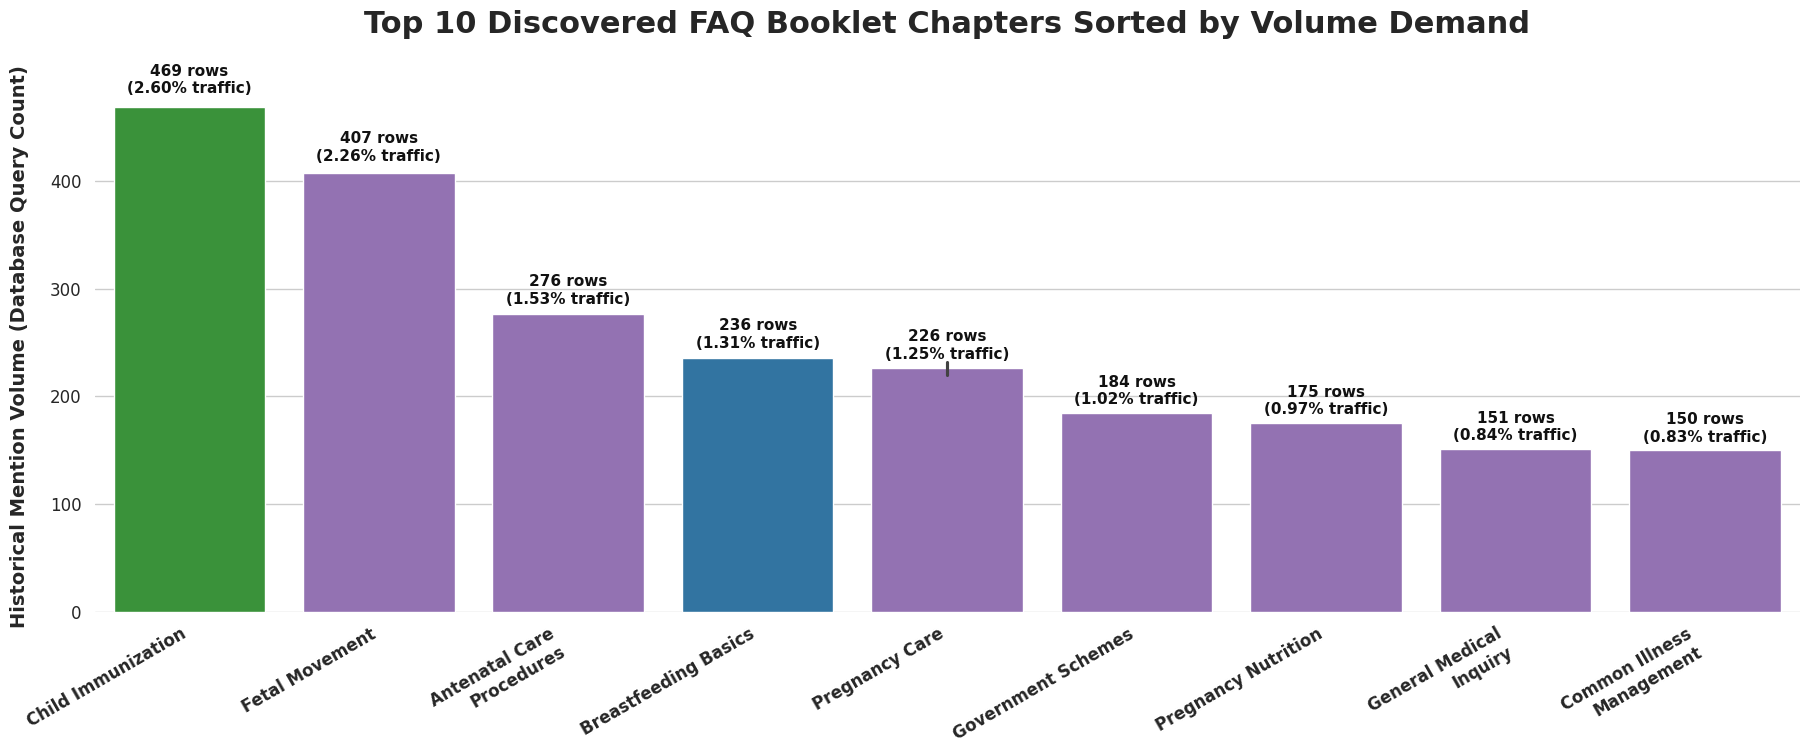

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import os

print("=== CELL 6.5: RENDERING PILLAR-COLORED CATEGORICAL DISTRIBUTION GRAPH ===")

def render_categorical_pillar_chart(booklet_csv_path, top_n_chapters=10):
    """
    Renders a high-fidelity Seaborn bar plot where each chapter's color
    is dynamically locked to its designated Clinical Pillar category,
    ensuring a pristine, readable executive layout.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Stream the newly generated high-resolution production dataset
    df_chart = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Clean and text wrap long Category names cleanly to avoid overlapping axis labels
    df_chart['wrapped_domain'] = df_chart['Domain_Category'].apply(
        lambda x: '\n'.join(textwrap.wrap(str(x).replace('_', ' ').title(), width=22))
    )

    # 2. Enforce your organization's signature boardroom color palette maps
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",          # Dark Slate Purple
        "👶 Pediatric & Infant Wellness": "#2ca02c",         # Medical Green
        "🏥 Labor & Delivery Preparation": "#ff7f0e",      # Warm Amber
        "🍼 Postpartum & Lactation Support": "#1f77b4"     # Clear Ocean Blue
    }

    # Map raw color vectors directly into a sequential layout list for Seaborn
    color_palette_list = [pillar_colors.get(p, "#7f7f7f") for p in df_chart['Clinical_Pillar']]

    # 3. Canvas Scene Setup Configurations
    plt.figure(figsize=(22, 10))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x='wrapped_domain',
        y='Total_User_Queries',
        data=df_chart,
        palette=color_palette_list,
        hue='wrapped_domain',
        legend=False
    )

    # 4. Polish Typography & Canvas Spacing Rules (Completely Emoji-Safe)
    plt.title('Top 10 Discovered FAQ Booklet Chapters Sorted by Volume Demand', fontsize=22, fontweight='bold', pad=35)
    plt.xlabel('', labelpad=15)
    plt.ylabel('Historical Mention Volume (Database Query Count)', fontsize=14, fontweight='bold', labelpad=15)

    # Format the tick label markers for executive presentation scannability
    plt.xticks(fontsize=12, fontweight='bold', rotation=30, ha='right')
    plt.yticks(fontsize=12)
    plt.subplots_adjust(bottom=0.35)

    # 5. Inject Absolute Row Counters Directly Atop Every Sky-Scraper Column Bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            # Calculate dynamic percentages locally relative to your overall dataset size
            share_pct = (height / 18044) * 100

            ax.text(
                p.get_x() + p.get_width()/2.,
                height + (height * 0.015) + 3, # Dynamic relative vertical padding clearance
                f"{int(height):,} rows\n({share_pct:.2f}% traffic)",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight='bold',
                color='#111111'
            )

    # Clean the plot borders for a modern presentation slide look
    sns.despine(left=True, bottom=True)
    plt.show()

# Target your newly created Top 10 spreadsheet data asset from disk panel storage
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv" # Update to top 10 name if different

render_categorical_pillar_chart(TARGET_BOOKLET_FILE, top_n_chapters=10)


In [43]:
len(final_upgraded_booklet_df)

10

In [44]:
final_upgraded_booklet_df.head(2)

,Booklet_Section,Clinical_Pillar,Target_KB_Markdown_File,System_Routing_Directive,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question,Domain_Category,Committee_Scope_of_Work,...,Top_7_Weighted_Bot_Anchors,Top_8_Distinct_Weighted_Questions,Cultural_Myths_To_Debunk,Core_Patient_Takeaway_Box,PLANNING_Sub_Intent_Distribution_Weights,INDEX_Cross_Lingual_Meta_Tags,INDEX_Phonetic_Invariants,INDEX_False_Positive_Shadow_Terms,GUARD_Hard_Bypass_Emergency_Triggers,GUARD_Semantic_Leakage_Warning
0,Chapter 1,👶 Pediatric & Infant Wellness,immunization_schedule_and_basics.md,ACTIVATE_IMMUNIZATION_MASTER_POOL,469,2.60% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule And...,CHILD IMMUNIZATION,The writers will create a comprehensive guide ...,...,[1] (Count: 6) Mera baby six month ka hua hai ...,[1] (Weight: 125 rows) What Should I Do If A L...,• You should not vaccinate a child if they hav...,Following the national immunization schedule i...,• Managing Post-Vaccine Side Effects (43.71%):...,"sui, soi, soyi, tika, teeka, tikka, tike, teek...","sui, tika, vaccine, injection, schedule","iron injection, anemia, dog bite, chuha, rabbi...","rabbit caat liya, chuha kar liya, animal bite,...",The cluster shows overlap with general pregnan...
1,Chapter 2,🤰 Maternal Antepartum Care,pregnancy_care_and_checkups.md,ISOLATE_PREGNANCY_PROCEDURE_LANE,407,2.26% of total channel traffic,Mothers are inquiring about the nature of feta...,What Is Considered Normal for Fetal Movement D...,FETAL MOVEMENT,The clinical scope is to provide comprehensive...,...,[1] (Count: 3) Pregnancy me pet upar ki traf c...,[1] (Weight: 80 rows) When Should I Expect to ...,"• The myth that the timing, location, or stren...",Regular fetal movement is a sign of a healthy ...,• Timing of First Movements (19.66%): Budget 1...,"momint, maumen, mumij, hal chal, hilne doolne,...","movement, halchal, kick, move, hilna, ghumna","pet dard, gas, acidity, delivery, labor pain, ...","no movement for 24 hours, baby not moving at a...",Warning: Queries about general abdominal sensa...


#done

#visuvalize

In [45]:
final_master_booklet_df = valid_clusters_df.copy()


In [46]:
!pip install adjustText

# below code is computes and  Run can takes 3 mins ..

In [47]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px
import plotly.graph_objects as go

print("=== CELL: GENERATING PLOTLY 2D INTERACTIVE MANIFOLD LANDSCAPE ===")

# 1. Safely locate the active dataframe containing the cluster definitions
source_df = None
cluster_col_name = None

for df_var_name, df_obj in [('valid_clusters_df', locals().get('valid_clusters_df')),
                            ('final_master_booklet_df', locals().get('final_master_booklet_df')),
                            ('df', locals().get('df'))]:
    if df_obj is not None:
        for col in ['cluster_id', 'Cluster', 'Cluster_ID']:
            if col in df_obj.columns:
                source_df = df_obj.copy()
                cluster_col_name = col
                print(f"✓ Successfully recovered cluster tracking data from variable: '{df_var_name}' (Column: '{col}')")
                break
        if source_df is not None:
            break

if source_df is None or len(source_df) == 0:
    raise ValueError("Could not locate a dataframe containing cluster IDs in memory. Please re-run your HDBSCAN clustering step.")

# 2. Reuse or compute 2D coordinates from your 3,072D production matrix
if 'two_d_embeddings' not in locals():
    print("• Computing 2D space layout embeddings...")
    viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
    two_d_embeddings = viz_reducer.fit_transform(normalized_embeddings)
else:
    print("✓ Reusing active 2D coordinates from memory cache.")

# Ensure the embeddings array shape exactly matches the extracted source dataframe length
if len(two_d_embeddings) != len(source_df):
    if len(two_d_embeddings) == 18044 and len(source_df) < 18044:
        two_d_embeddings = two_d_embeddings[source_df.index]

# 3. Pull human-readable titles from your generated Top 10 booklet dataframe
id_to_domain = {}
id_to_question = {}

if 'final_upgraded_booklet_df' in locals():
    top_10_chapters = final_upgraded_booklet_df.head(10).copy()
    unique_active_cids = sorted(source_df[source_df[cluster_col_name] != -1][cluster_col_name].unique())

    for idx, row in top_10_chapters.iterrows():
        if idx < len(unique_active_cids):
            cid_val = unique_active_cids[idx]
            domain_title = str(row.get('Domain_Category', f'Topic {cid_val}')).replace('_', ' ').title()
            canonical_q = row.get('Top_Canonical_FAQ_Question', '')

            id_to_domain[cid_val] = f"Ch {idx+1}: {domain_title}"
            id_to_question[cid_val] = canonical_q

# Map remaining values to clean fallbacks
for cid_val in source_df[cluster_col_name].unique():
    if cid_val == -1:
        id_to_domain[cid_val] = "Background Noise (Filtered)"
        id_to_question[cid_val] = "N/A"
    elif cid_val not in id_to_domain:
        id_to_domain[cid_val] = f"Cluster {cid_val} (Long-Tail)"
        id_to_question[cid_val] = "Unclassified Intent Link"

# 4. Compile visualization DataFrame matrix
plot_df = pd.DataFrame(two_d_embeddings, columns=['X_Coordinate', 'Y_Coordinate'])
plot_df['Cluster_ID'] = source_df[cluster_col_name].values
plot_df['Raw_WhatsApp_Text'] = source_df['body_final_phonetic'].values
plot_df['Display_Group'] = plot_df['Cluster_ID'].map(id_to_domain)
plot_df['Canonical_FAQ'] = plot_df['Cluster_ID'].map(id_to_question)

# Filter display size slightly to ensure highly responsive panning inside the notebook environment
display_slice = plot_df.sample(n=min(6000, len(plot_df)), random_state=42)

# 5. Generate Interactive Plotly Graph
fig = px.scatter(
    display_slice,
    x='X_Coordinate',
    y='Y_Coordinate',
    color='Display_Group',
    title='<b>Geometric Mapping of Community Health FAQ Clusters (UMAP Space)</b>',
    labels={'X_Coordinate': 'Semantic Manifold Component 1', 'Y_Coordinate': 'Semantic Manifold Component 2'},
    hover_data={'Raw_WhatsApp_Text': True, 'Display_Group': True, 'Canonical_FAQ': True, 'X_Coordinate': False, 'Y_Coordinate': False},
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.75
)

# 6. Calculate cluster spatial centroids and draw pointer annotations
if 'final_upgraded_booklet_df' in locals():
    for idx, cid in enumerate(unique_active_cids[:10]):
        cluster_coords = plot_df[plot_df['Cluster_ID'] == cid]
        if len(cluster_coords) == 0: continue

        centroid_x = cluster_coords['X_Coordinate'].mean()
        centroid_y = cluster_coords['Y_Coordinate'].mean()

        # Route annotation labels in a circular layout pattern around the graph to avoid crossing lines
        angle = (idx * (2 * np.pi / 10))
        offset_x = 1.3 * np.cos(angle)
        offset_y = 1.3 * np.sin(angle)

        short_label = id_to_domain.get(cid, f"Cluster #{cid}")
        if len(short_label) > 28: short_label = short_label[:25] + "..."

        fig.add_annotation(
            x=centroid_x, y=centroid_y,
            ax=centroid_x + offset_x, ay=centroid_y + offset_y,
            text=f"<b>{short_label}</b>",
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1.5, arrowcolor='#607d8b',
            font=dict(size=10, color='#111111'),
            bgcolor='white', bordercolor='#cfd8dc', borderwidth=1, borderpad=3, opacity=0.92
        )

# 7. Finalize layout design configurations
fig.update_layout(
    template='plotly_white',
    width=1150,
    height=800,
    title_font=dict(size=18, family="Arial, sans-serif"),
    legend_title_text='Discovered Intent Categories',
    hovermode='closest'
)

fig.update_traces(marker=dict(size=6, line=dict(width=0.2, color='White')))

# Fixed axis label formatting syntax matching Plotly's Font object rules
fig.update_xaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))
fig.update_yaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))

print("🎉 Success! Plotly manifold visualization is ready below.")
fig.show()


=== CELL: GENERATING PLOTLY 2D INTERACTIVE MANIFOLD LANDSCAPE ===
✓ Successfully recovered cluster tracking data from variable: 'valid_clusters_df' (Column: 'cluster_id')
• Computing 2D space layout embeddings...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



🎉 Success! Plotly manifold visualization is ready below.
